Missing values:
 Age                     0
Gender                  0
Occupation              0
Income                  0
WebsiteVisits           0
PreviousPurchases       0
TotalSpent              0
MarketingInteraction    0
Purchased               0
dtype: int64


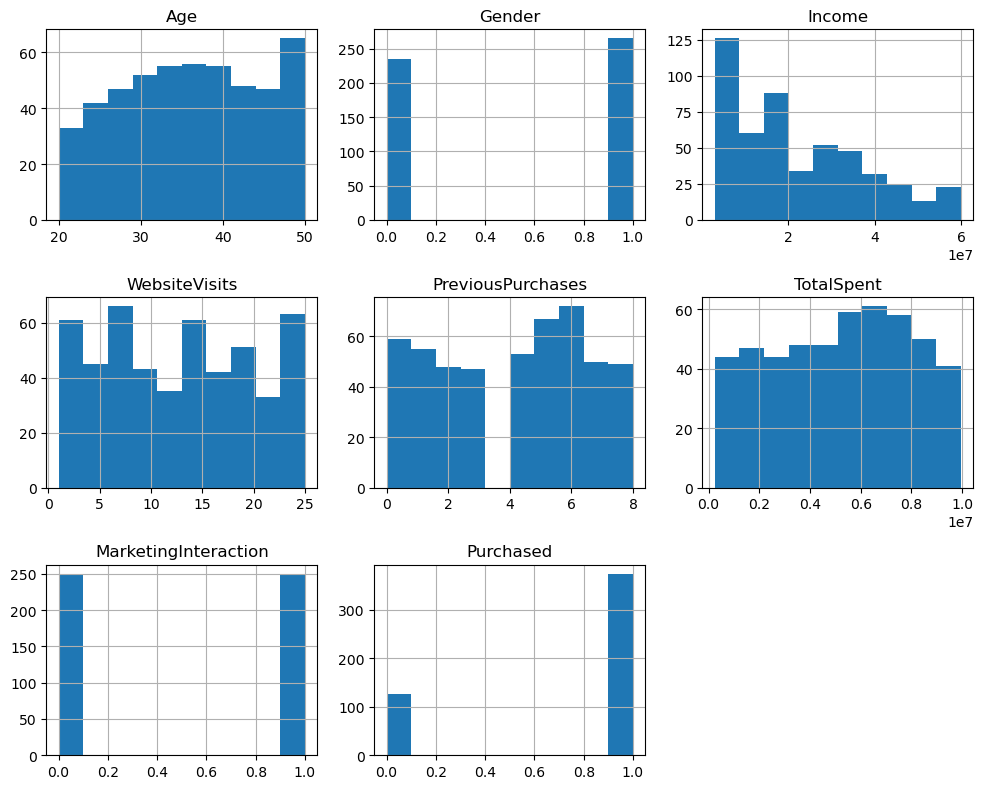

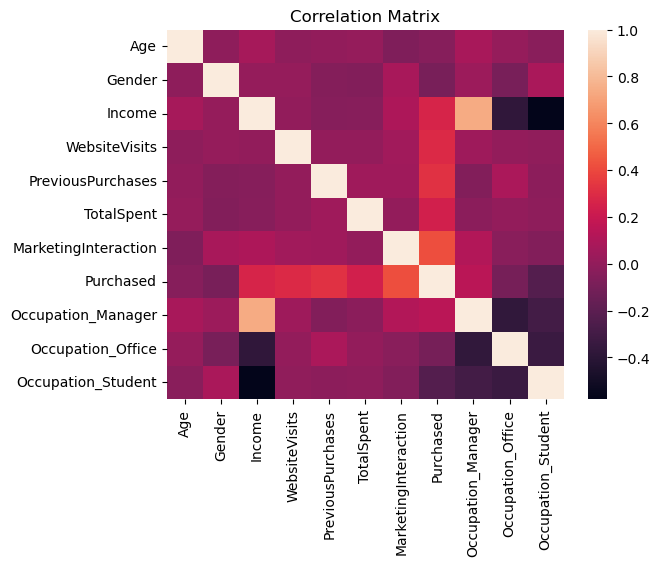

=== MODEL EVALUATION ===
Accuracy: 0.92
Precision: 0.9256198347107438
Recall: 0.9739130434782609
F1-score: 0.9491525423728814

Confusion Matrix:
 [[ 26   9]
 [  3 112]]


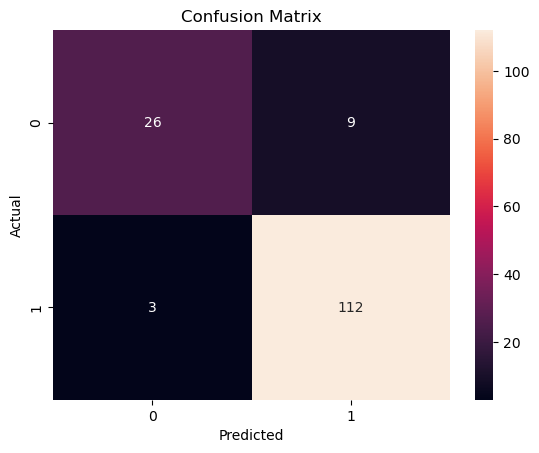

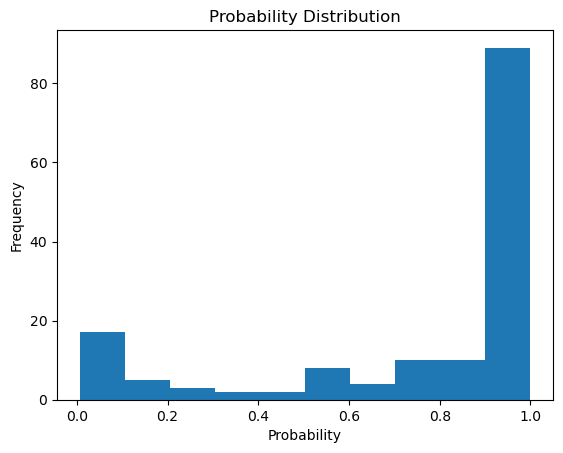

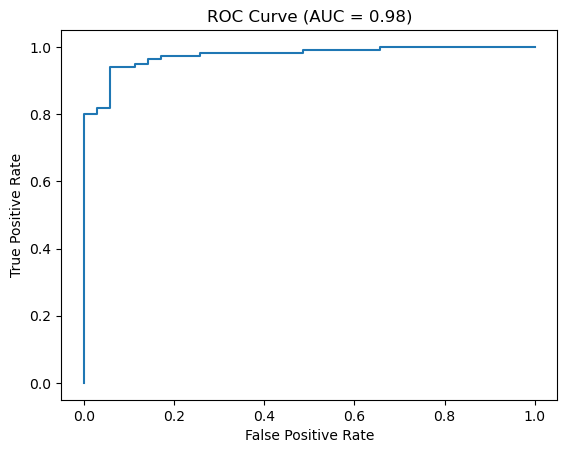


=== COEFFICIENTS ===
                Feature  Coefficient
9    Occupation_Student    -0.828605
8     Occupation_Office    -0.812914
7    Occupation_Manager    -0.353989
1                Gender    -0.340994
0                   Age    -0.142701
2                Income     1.044450
5            TotalSpent     1.057501
3         WebsiteVisits     1.438773
4     PreviousPurchases     1.500103
6  MarketingInteraction     1.723808


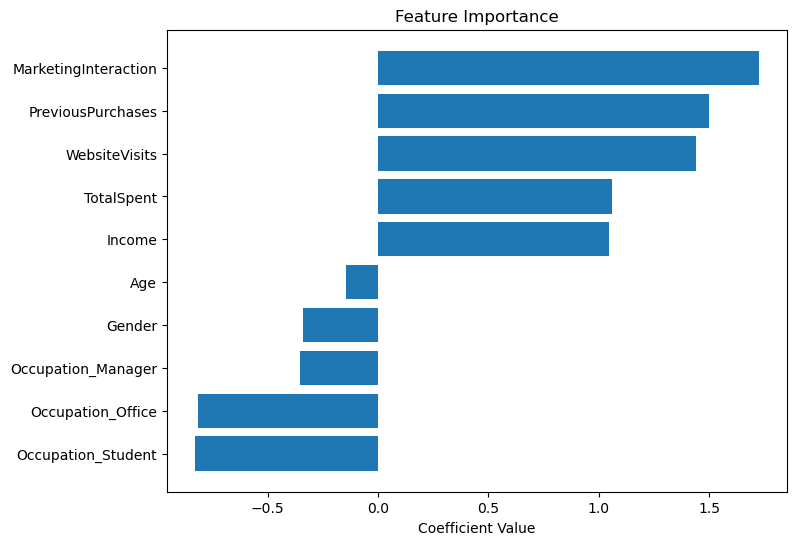


Best Parameters: {'C': 10, 'solver': 'liblinear'}
Model saved successfully!

=== NEW CUSTOMER PREDICTION ===
Xác suất mua: 89.67 %
Kết luận: Tiềm năng


In [2]:
# ==============================
# 1. IMPORT THƯ VIỆN
# ==============================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
# ==============================
# 2. ĐỌC DỮ LIỆU
# ==============================
df = pd.read_csv("customer_data.csv")

# ==============================
# 3. LÀM SẠCH DỮ LIỆU
# ==============================
# Kiểm tra dữ liệu
print("Missing values:\n", df.isnull().sum())

# Xử lý dữ liệu thiếu
df = df.dropna()

# Xóa dữ liệu trùng
df = df.drop_duplicates()

# ==============================
# 4. MÃ HÓA BIẾN PHÂN LOẠI
# ==============================
# One-Hot Encoding cho Occupation
df = pd.get_dummies(df, columns=["Occupation"], drop_first=True)
# ==============================
# 5. TRỰC QUAN HÓA DỮ LIỆU
# ==============================

# Histogram
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.savefig("histogram.png")
plt.show()

# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Matrix")
plt.savefig("correlation.png")
plt.show()
# ==============================
# 6. TÁCH BIẾN X, y
# ==============================
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

# ==============================
# 7. CHIA TRAIN / TEST (70/30)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
# ==============================
# 8. CHUẨN HÓA DỮ LIỆU
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 9. HUẤN LUYỆN MÔ HÌNH
# ==============================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ==============================
# 10. DỰ ĐOÁN
# ==============================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ==============================
# 11. ĐÁNH GIÁ MÔ HÌNH
# ==============================
print("=== MODEL EVALUATION ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
     
# ==============================
# 12. VẼ CONFUSION MATRIX
# ==============================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

# ==============================
# 13. BIỂU ĐỒ XÁC SUẤT
# ==============================
plt.figure()
plt.hist(y_prob, bins=10)
plt.title("Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.savefig("probability.png")
plt.show()

# ==============================
# 14. ROC CURVE
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig("roc_curve.png")
plt.show()
# ==============================
# 15. HIỂN THỊ HỆ SỐ HỒI QUY
# ==============================
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient")

print("\n=== COEFFICIENTS ===")
print(coefficients)

# Vẽ biểu đồ hệ số
plt.figure(figsize=(8, 6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.savefig("coefficients.png")
plt.show()

# ==============================
# 16. TUNING THAM SỐ (GRID SEARCH)
# ==============================
param_grid = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# Cập nhật model tốt nhất
model = grid.best_estimator_

# ==============================
# 17. LƯU MODEL
# ==============================
joblib.dump(model, "customer_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")
# ==============================
# 18. KIỂM THỬ KHÁCH HÀNG MỚI
# ==============================
new_customer = pd.DataFrame([{
    "Age": 30,
    "Gender": 0,
    "Income": 12000000,
    "WebsiteVisits": 12,
    "PreviousPurchases": 3,
    "TotalSpent": 3000000,
    "MarketingInteraction": 1,
    
    # cứ khai báo theo hiểu biết
    "Occupation_Office": 1,
    "Occupation_Business": 0,
    "Occupation_Manager": 0
}])

new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

# chuẩn hóa
new_customer = scaler.transform(new_customer)

prob = model.predict_proba(new_customer)[0][1]
prediction = model.predict(new_customer)[0]

print("\n=== NEW CUSTOMER PREDICTION ===")
print("Xác suất mua:", round(prob * 100, 2), "%")
print("Kết luận:", "Tiềm năng" if prediction == 1 else "Không tiềm năng")